# **Heart Diesease Prediction Project**

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
features=pd.read_csv("D:\\project testing\\PRCP-1016-HeartDieseasePred\\Data\\values.csv")

In [3]:
labels=pd.read_csv("D:\\project testing\\PRCP-1016-HeartDieseasePred\\Data\\labels.csv")

In [4]:
data=pd.merge(features,labels,on='patient_id')

In [5]:
data

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


## **Basic Checks**

In [6]:
data.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [7]:
data.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [8]:
data.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [10]:
data.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

## **Data Analysis And Visualization**

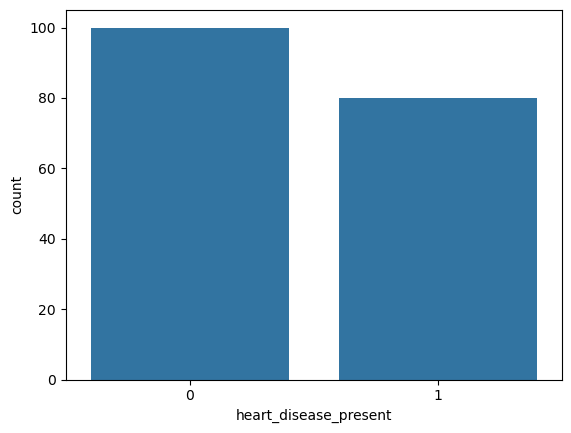

In [11]:
sns.countplot(data=data,x='heart_disease_present')
plt.show()

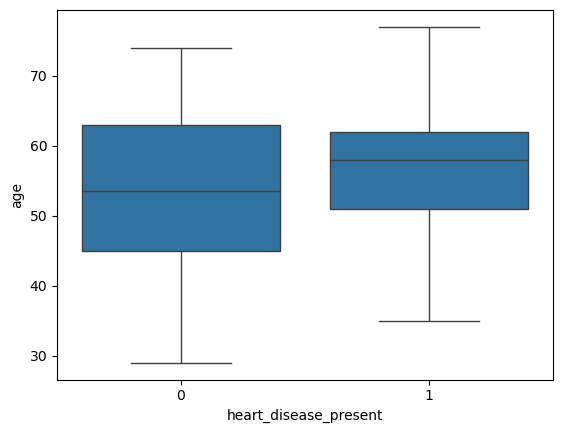

In [12]:
sns.boxplot(data=data,x='heart_disease_present',y='age')
plt.show()

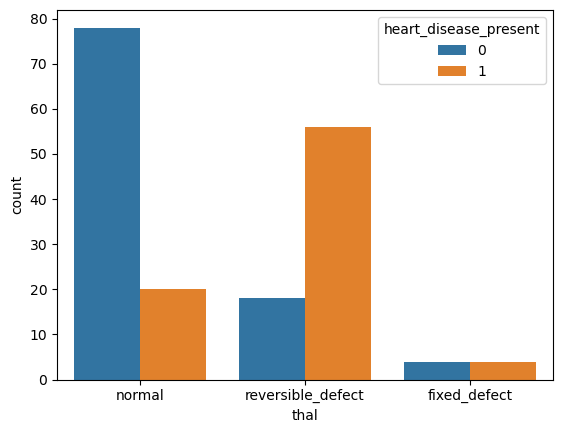

In [13]:
sns.countplot(data=data,x='thal',hue='heart_disease_present')
plt.show()

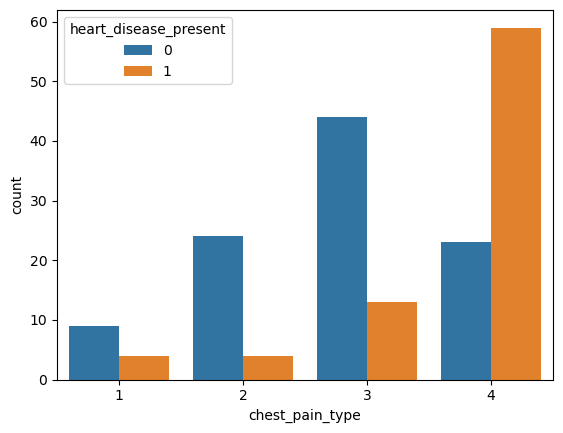

In [14]:
sns.countplot(data=data,x='chest_pain_type',hue='heart_disease_present')
plt.show()

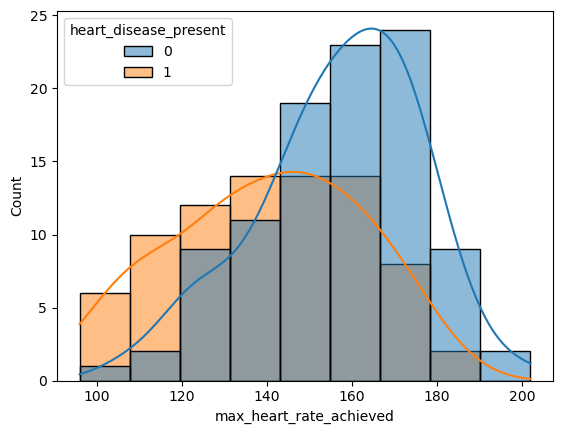

In [15]:
sns.histplot(data=data,x='max_heart_rate_achieved',hue='heart_disease_present',kde=True)
plt.show()

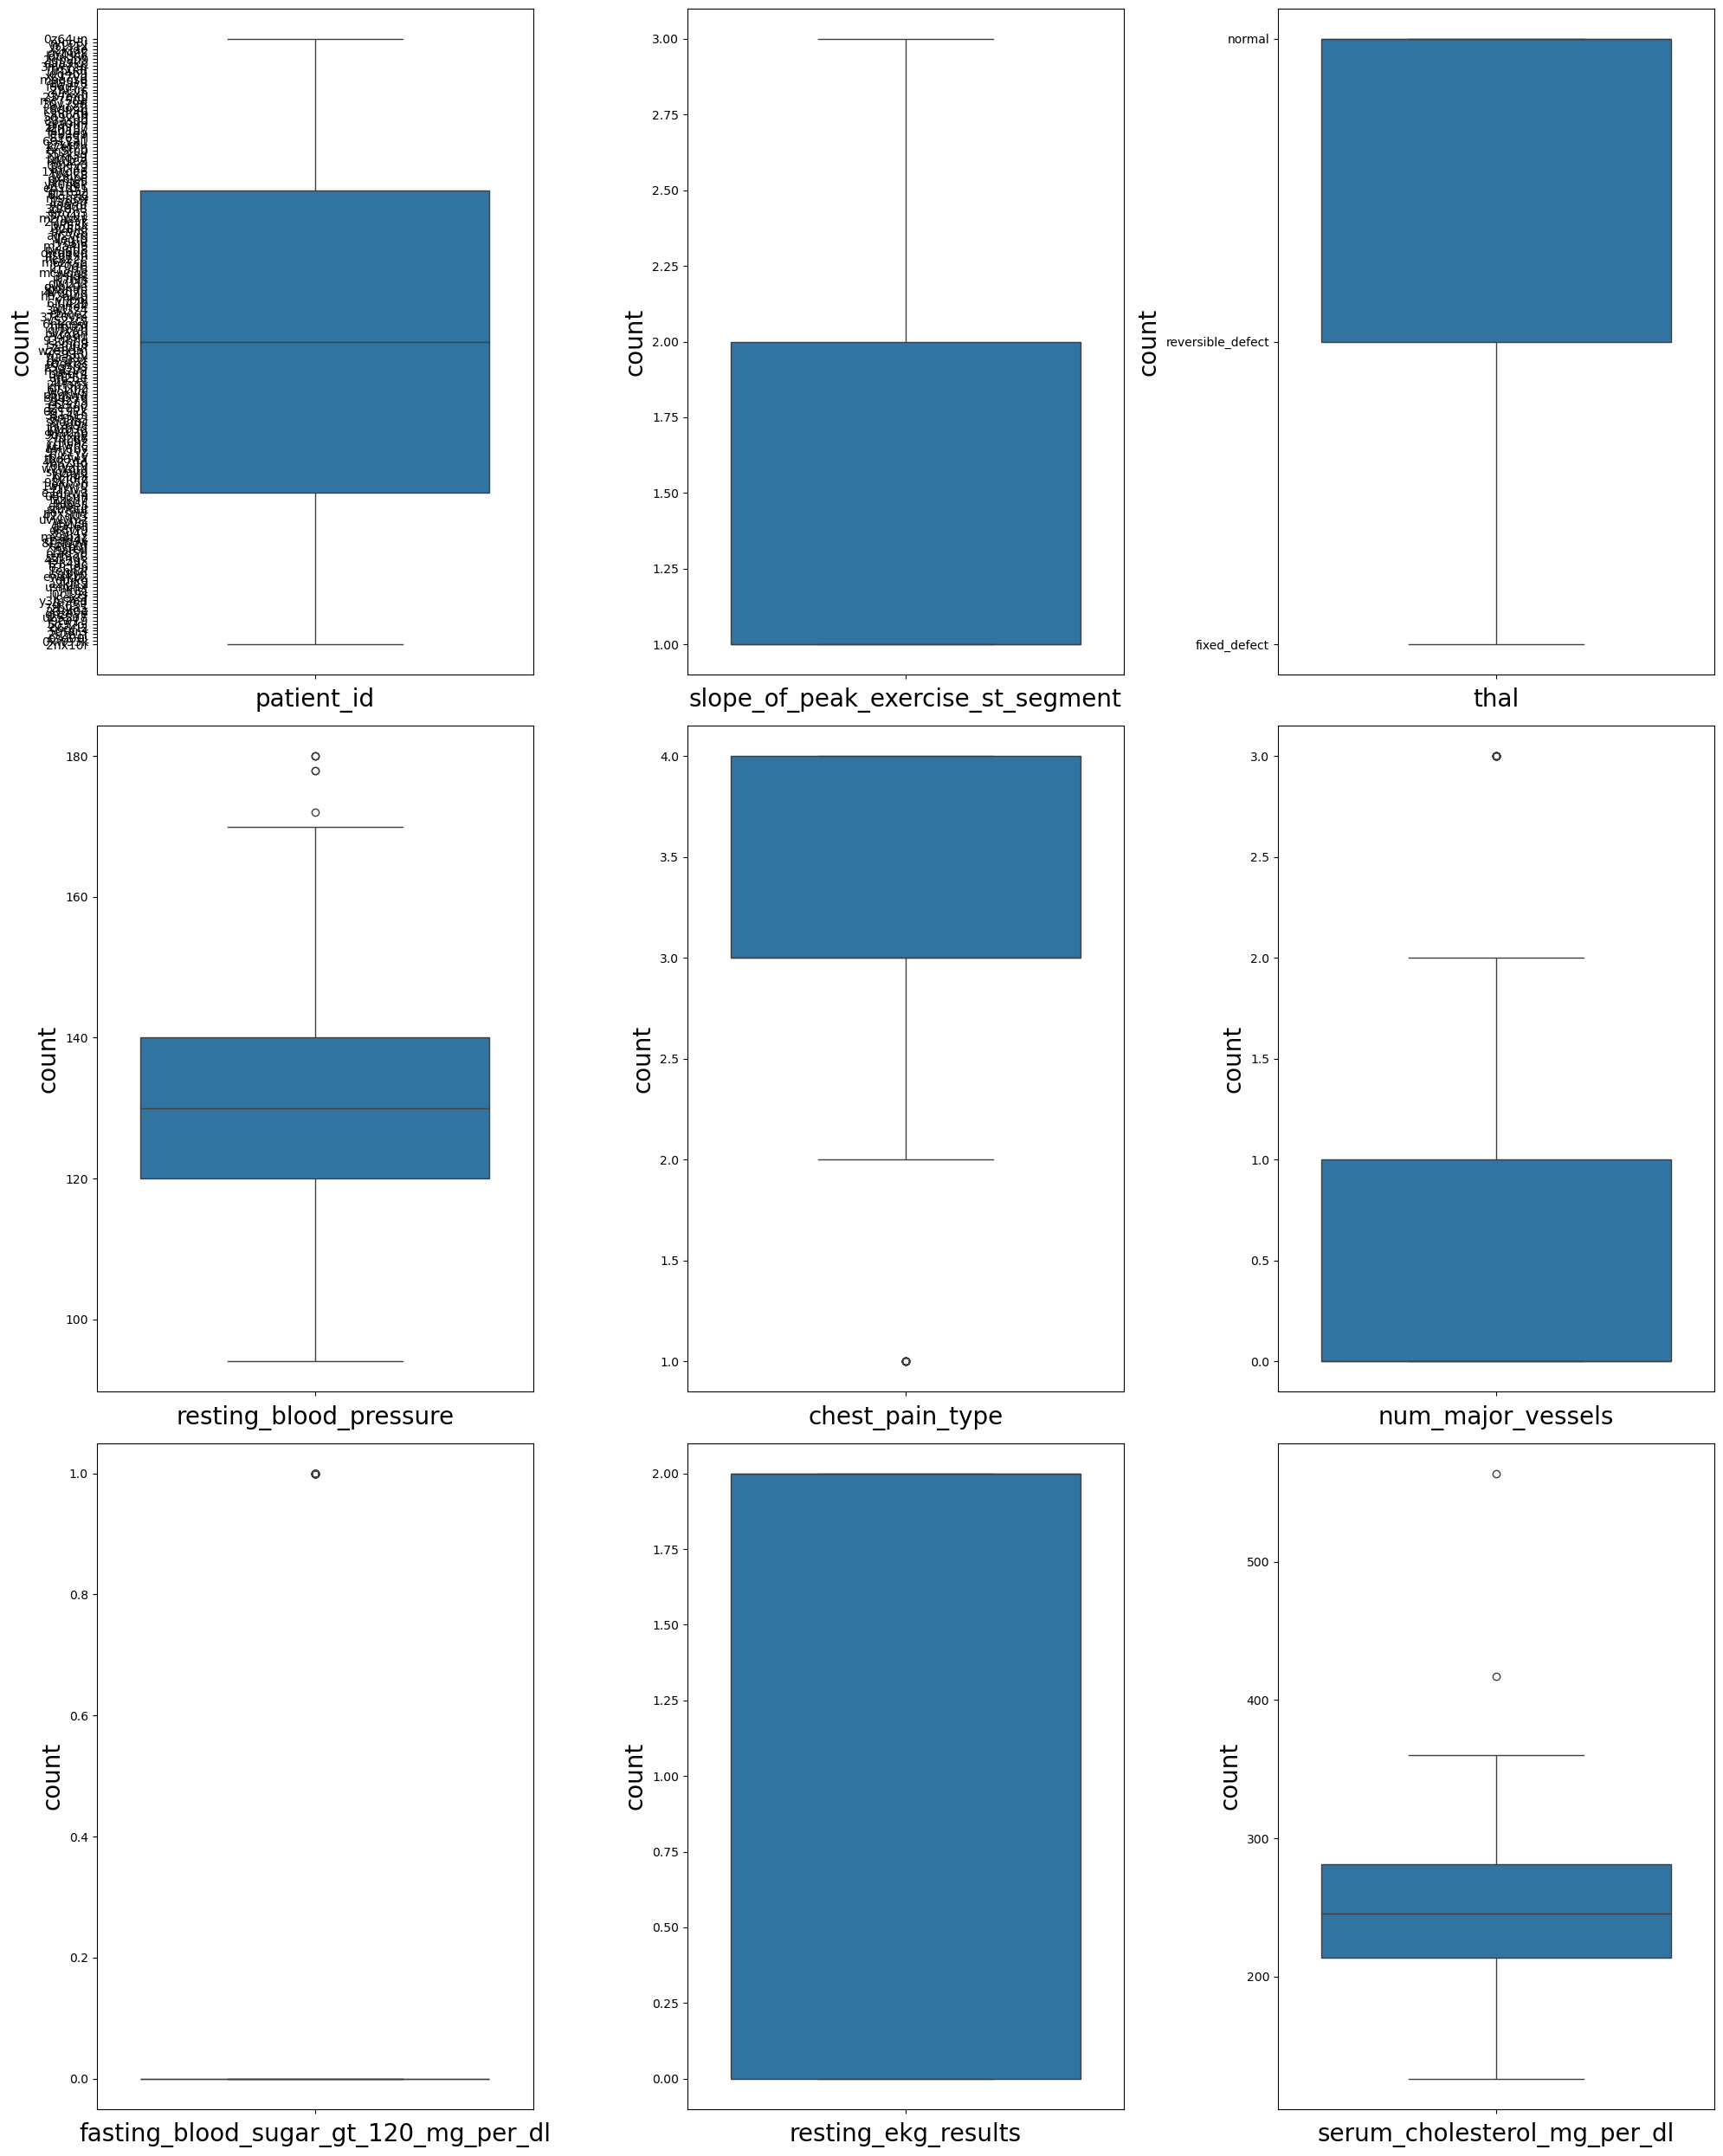

In [16]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in data:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.boxplot(data[column])
        plt.xlabel(column,fontsize=20)
        plt.ylabel('count',fontsize=20)
        plotnumber+=1

plt.tight_layout()
plt.show()

## **Data Preprocessing**

In [17]:
data.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [18]:
data.drop('patient_id',axis=1,inplace=True)

In [19]:
data['high_bp']=(data['resting_blood_pressure']>140).astype(int)

In [20]:
data['high_cholesterol']=(data['serum_cholesterol_mg_per_dl']>240).astype(int)

In [21]:
data['elderly']=(data['age']>60).astype(int)

In [22]:
data['dangerous_chest_pain']=(data['chest_pain_type']==4).astype(int)

In [23]:
data

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,high_bp,high_cholesterol,elderly,dangerous_chest_pain
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0,0,1,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0,0,0,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1,0,1,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1,1,0,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1,0,1,1,1
176,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1,1,1,0,1
177,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1,0,1,1,0
178,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0,0,1,0,0


In [24]:
def cap_ouliers_iqr(data,column):
    Q1=data[column].quantile(0.25)
    Q3=data[column].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    data[column]=np.where(data[column]<lower,lower,data[column])
    data[column]=np.where(data[column]>upper,upper,data[column])
    return data

In [25]:
columns_with_outliers=['resting_blood_pressure','serum_cholesterol_mg_per_dl','oldpeak_eq_st_depression','num_major_vessels']
for col in columns_with_outliers:
    data=cap_ouliers_iqr(data,col)

In [26]:
numeric_cols=data.select_dtypes(include=['int64','float64']).columns
log_transform_cols=[col for col in numeric_cols if data[col].skew()>1 and(data[col]>0).all()]
for col in log_transform_cols:
    data[col]=np.log1p(data[col])

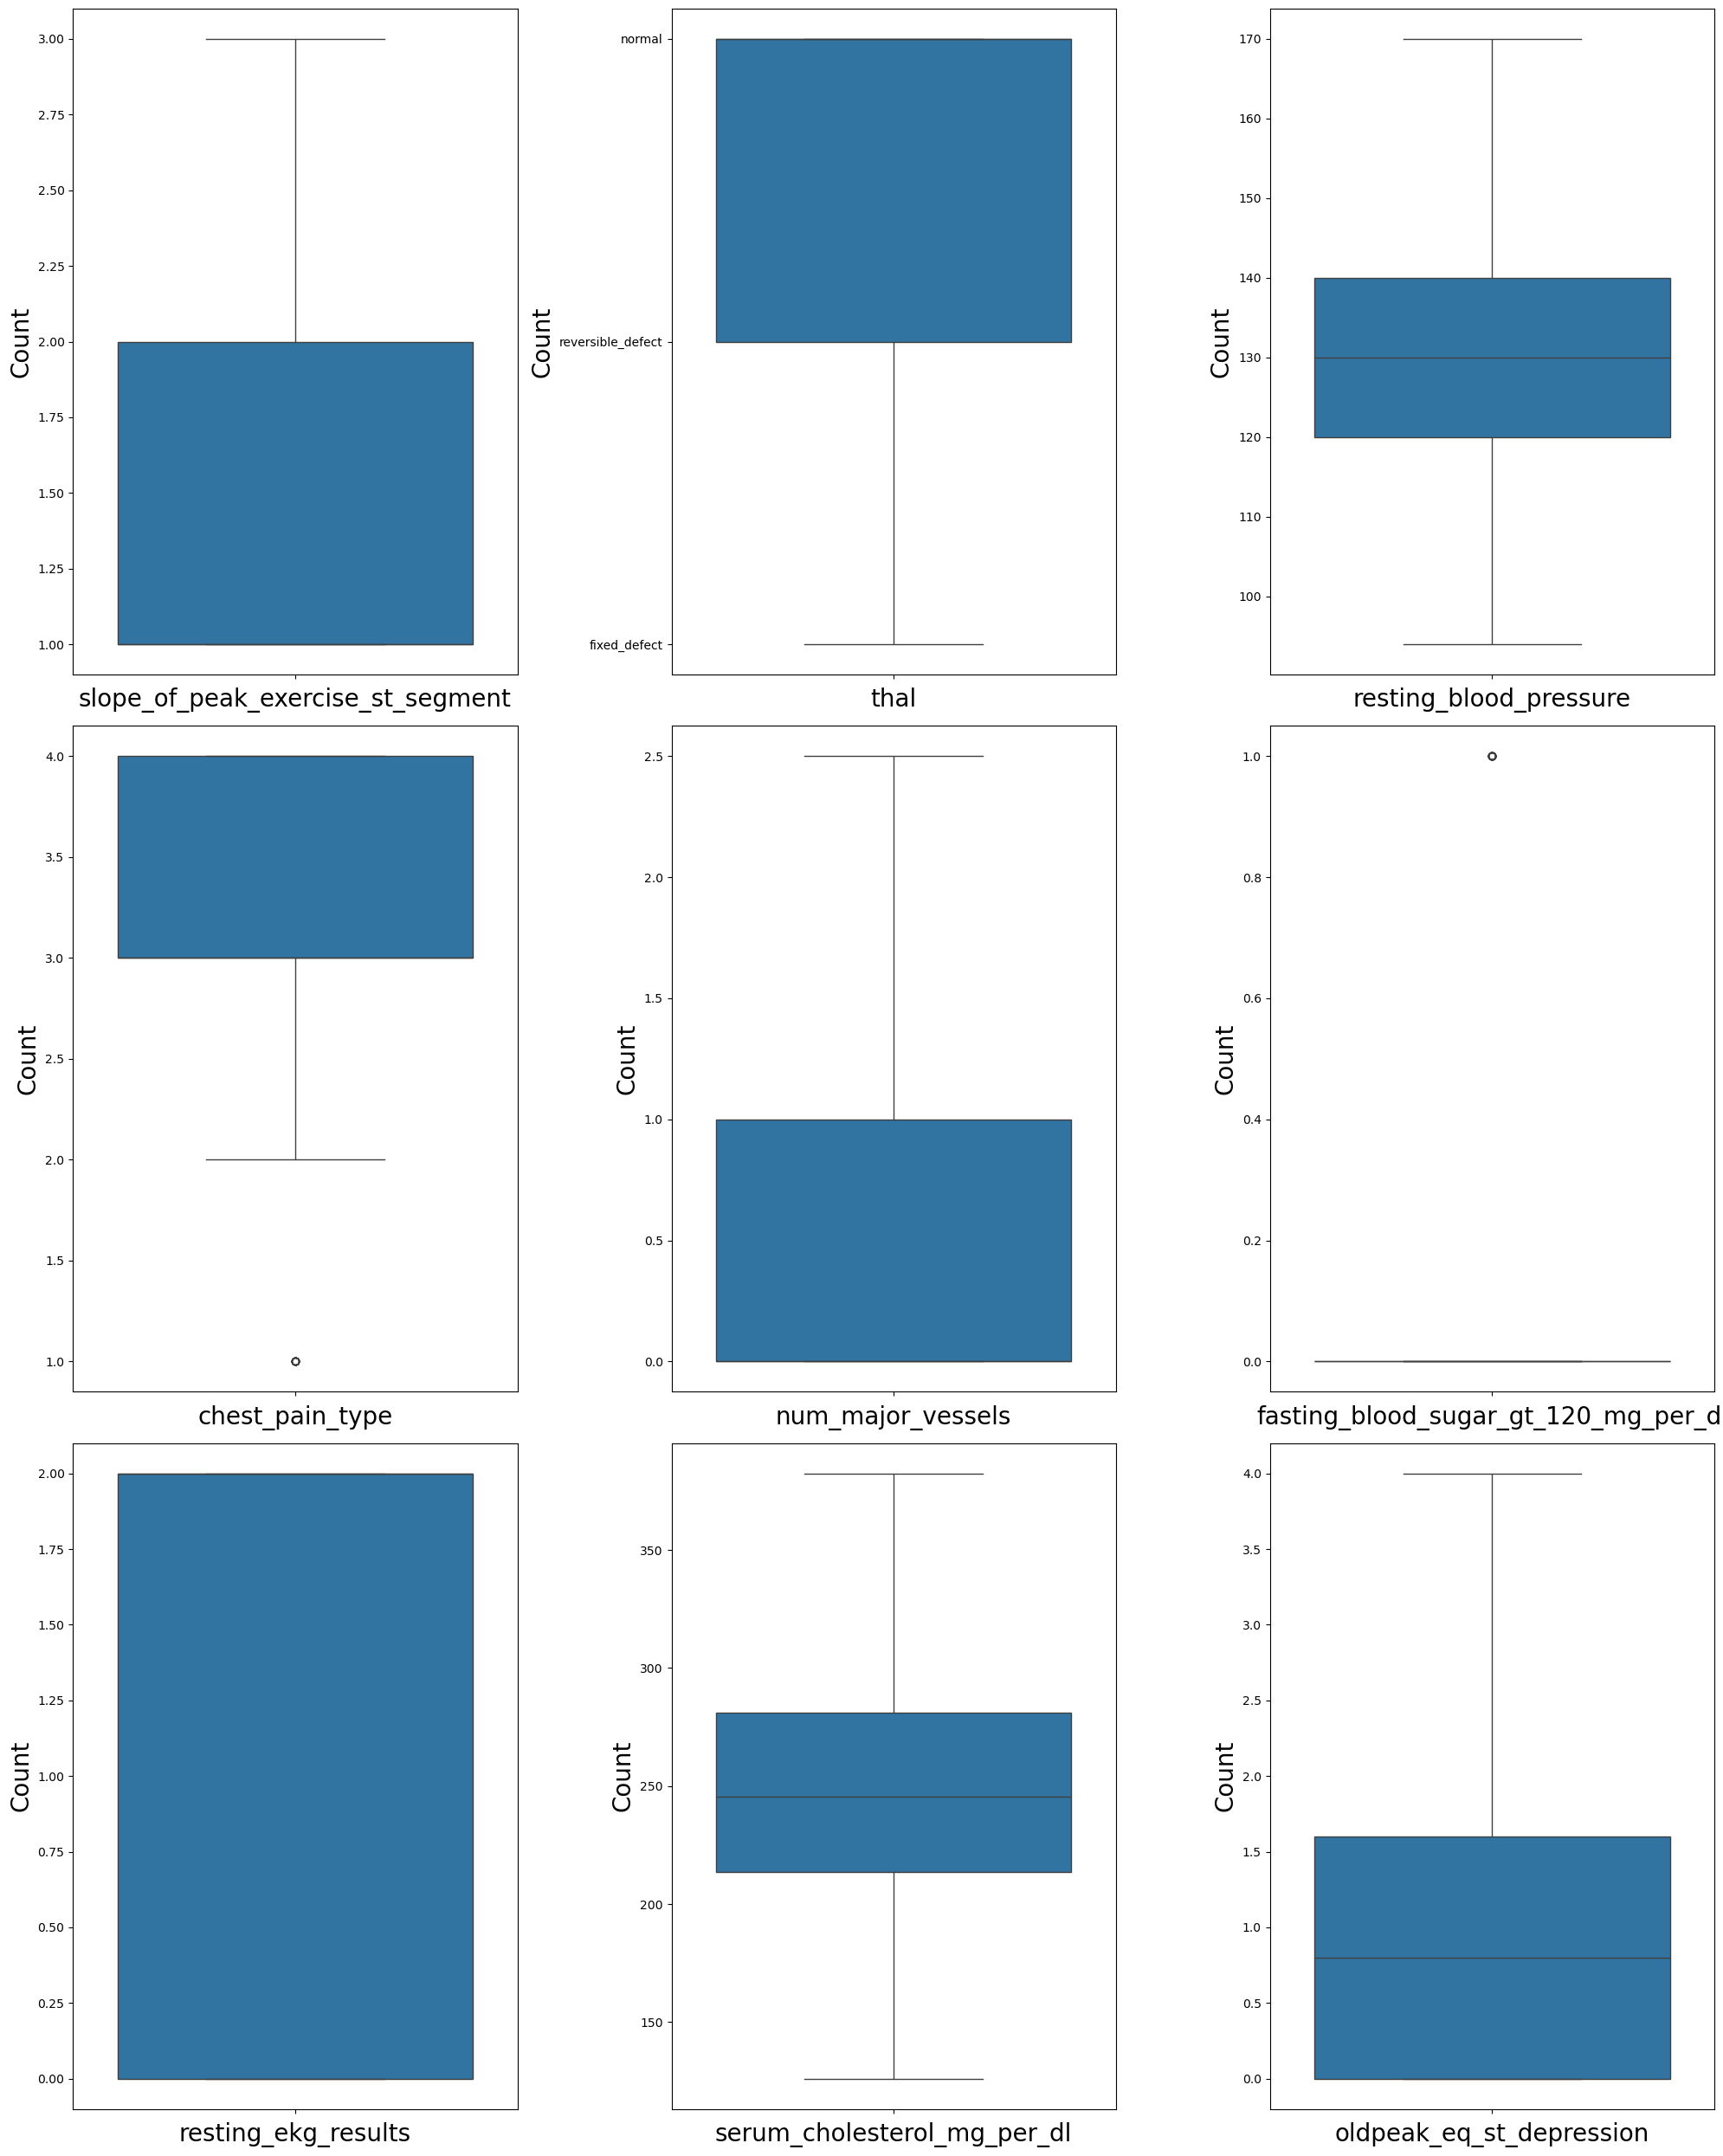

In [27]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in data:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.boxplot(data[column])
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    plotnumber+=1
plt.tight_layout()
plt.show()

In [28]:
data['fasting_blood_sugar_gt_120_mg_per_dl'].unique()

array([0, 1])

In [29]:
data=data[data['fasting_blood_sugar_gt_120_mg_per_dl'].isin([0,1])]

## **Data Preprocessing And Feature Engineering**

In [30]:
data.head()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,high_bp,high_cholesterol,elderly,dangerous_chest_pain
0,1,normal,128.0,2,0.0,0,2,308.0,0.0,1,45,170,0,0,0,1,0,0
1,2,normal,110.0,3,0.0,0,0,214.0,1.6,0,54,158,0,0,0,0,0,0
2,1,normal,125.0,4,2.5,0,2,304.0,0.0,1,77,162,1,1,0,1,1,1
3,1,reversible_defect,152.0,4,0.0,0,0,223.0,0.0,1,40,181,0,1,1,0,0,1
4,3,reversible_defect,170.0,1,0.0,0,2,270.0,4.0,1,59,145,0,0,1,1,0,0


### **Encoding**

In [31]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['thal']=le.fit_transform(data['thal'])

In [32]:
data.head()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,high_bp,high_cholesterol,elderly,dangerous_chest_pain
0,1,1,128.0,2,0.0,0,2,308.0,0.0,1,45,170,0,0,0,1,0,0
1,2,1,110.0,3,0.0,0,0,214.0,1.6,0,54,158,0,0,0,0,0,0
2,1,1,125.0,4,2.5,0,2,304.0,0.0,1,77,162,1,1,0,1,1,1
3,1,2,152.0,4,0.0,0,0,223.0,0.0,1,40,181,0,1,1,0,0,1
4,3,2,170.0,1,0.0,0,2,270.0,4.0,1,59,145,0,0,1,1,0,0


### **Scaling Data**

In [33]:
from sklearn.preprocessing import StandardScaler
scale_columns=['age','resting_blood_pressure','serum_cholesterol_mg_per_dl','max_heart_rate_achieved','oldpeak_eq_st_depression','num_major_vessels']
scaler=StandardScaler()
data[scale_columns]=scaler.fit_transform(data[scale_columns])

In [34]:
data[scale_columns]

,age,resting_blood_pressure,serum_cholesterol_mg_per_dl,max_heart_rate_achieved,oldpeak_eq_st_depression,num_major_vessels
0,-1.053964,-0.187145,1.263895,0.932485,-0.954372,-0.745612
1,-0.087134,-1.293623,-0.716574,0.387084,0.593258,-0.745612
2,2.383654,-0.371558,1.179619,0.568884,-0.954372,2.097823
3,-1.591092,1.288159,-0.526954,1.432436,-0.954372,-0.745612
4,0.449994,2.394637,0.463280,-0.203768,2.914704,-0.745612
...,...,...,...,...,...,...
175,1.309398,-0.371558,0.126179,0.614334,-0.760918,1.529136
176,0.020291,2.394637,1.664202,-1.476372,2.334342,-0.745612
177,0.987122,-0.371558,1.284963,-0.840070,0.786712,-0.745612
178,-0.731688,-0.433029,0.147248,1.159736,-0.954372,1.529136


In [35]:
data.describe()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,high_bp,high_cholesterol,elderly,dangerous_chest_pain
count,180.000000,180.000000,1.800000e+02,180.000000,1.800000e+02,180.000000,180.000000,1.800000e+02,1.800000e+02,180.000000,1.800000e+02,1.800000e+02,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,1.366667,-4.243519e-16,3.155556,3.207311e-17,0.161111,1.050000,-1.973730e-16,-1.430954e-16,0.688889,1.295260e-16,6.019876e-16,0.316667,0.444444,0.205556,0.533333,0.294444,0.455556
std,0.618838,0.568247,1.002789e+00,0.938454,1.002789e+00,0.368659,0.998742,1.002789e+00,1.002789e+00,0.464239,1.002789e+00,1.002789e+00,0.466474,0.498290,0.405234,0.500279,0.457064,0.499410
min,1.000000,0.000000,-2.277159e+00,1.000000,-7.456119e-01,0.000000,0.000000,-2.570629e+00,-9.543721e-01,0.000000,-2.772773e+00,-2.430824e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,-6.789130e-01,3.000000,-7.456119e-01,0.000000,0.000000,-7.218409e-01,-9.543721e-01,0.000000,-7.316875e-01,-7.946197e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,-6.420304e-02,3.000000,-7.456119e-01,0.000000,2.000000,-5.290613e-02,-1.805569e-01,1.000000,2.029150e-02,1.143828e-01,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,2.000000,2.000000,5.505069e-01,4.000000,3.917622e-01,0.000000,2.000000,7.003039e-01,5.932583e-01,1.000000,7.722705e-01,7.620471e-01,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,3.000000,2.000000,2.394637e+00,4.000000,2.097823e+00,1.000000,2.000000,2.833521e+00,2.914704e+00,1.000000,2.383654e+00,2.386889e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


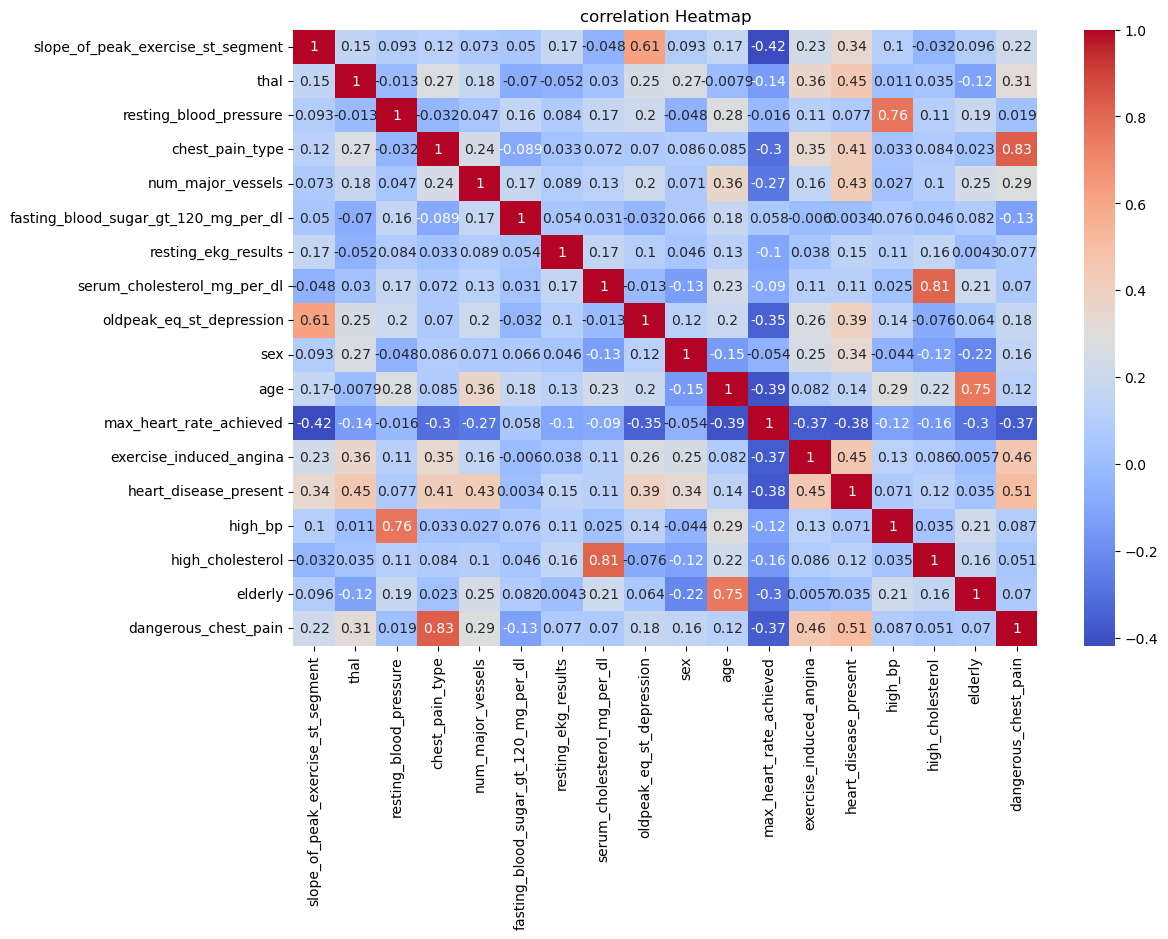

In [36]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title("correlation Heatmap")
plt.show()

## **Model Creation**

In [37]:
x=data.drop(['heart_disease_present'],axis=1)
y=data['heart_disease_present']

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [39]:
from imblearn.over_sampling import SMOTE 
sm=SMOTE(random_state=42)
x_train_sm,y_train_sm=sm.fit_resample(x_train,y_train)

c:\Users\Admin\anaconda3\envs\mlproj\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## **Logistic Regression**

In [40]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)

In [41]:

model.fit(x_train_sm,y_train_sm)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [42]:
y_pred=model.predict(x_test)
y_pred

array([0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1])

In [43]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81        20
           1       0.74      0.88      0.80        16

    accuracy                           0.81        36
   macro avg       0.81      0.81      0.81        36
weighted avg       0.82      0.81      0.81        36



In [44]:
print(accuracy_score(y_test,y_pred))

0.8055555555555556


In [45]:
from sklearn.metrics import recall_score
recall=recall_score(y_test,y_pred)
print(f"Recall Score:{recall:.2f}")

Recall Score:0.88


## **Confusion Matrix And ROC_AUC_SCORE**

In [46]:
from sklearn.metrics import confusion_matrix,roc_auc_score,ConfusionMatrixDisplay
y_pred=model.predict(x_test)
y_proba=model.predict_proba(x_test)[:,1]

In [47]:
y_proba

array([0.19765711, 0.89532964, 0.91876882, 0.13616207, 0.21753306,
       0.52973151, 0.34310599, 0.37992596, 0.9699126 , 0.98915406,
       0.24222124, 0.99832719, 0.82902938, 0.93027924, 0.03010898,
       0.5136452 , 0.06149149, 0.9363877 , 0.58401377, 0.9362956 ,
       0.98929308, 0.99815946, 0.96823171, 0.35241301, 0.05455337,
       0.02247276, 0.01615319, 0.03340168, 0.99789553, 0.34753063,
       0.48976009, 0.99218871, 0.99531669, 0.3026757 , 0.04593196,
       0.8912694 ])

In [48]:
print("ROC-AUC Score:",roc_auc_score(y_test,y_proba))

ROC-AUC Score: 0.934375


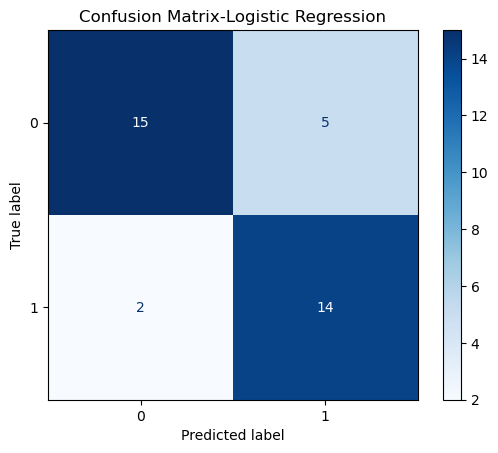

In [49]:
ConfusionMatrixDisplay.from_estimator(model,x_test,y_test,cmap='Blues')
plt.title("Confusion Matrix-Logistic Regression")
plt.show()

In [50]:
y_pred_train = model.predict(x_train)
accuracy_score(y_pred_train, y_train)

0.8472222222222222

In [51]:
y_pred_test=model.predict(x_test)
accuracy_score(y_pred_test,y_test)

0.8055555555555556

## **Cross Validation**

In [52]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x_train,y_train,cv=5)
print("cross-validation scores:",scores)
print("Average accuracy:",scores.mean())

cross-validation scores: [0.86206897 0.72413793 0.79310345 0.79310345 0.82142857]
Average accuracy: 0.798768472906404


## **Decision Tree Classifier**

In [53]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(max_depth=4,min_samples_split=5,criterion='entropy',random_state=42)
dt_model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_split=5,
                       random_state=42)

In [54]:
y_pred_dt=dt_model.predict(x_test)
y_pred_dt

array([0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0])

In [55]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.73      0.80      0.76        20
           1       0.71      0.62      0.67        16

    accuracy                           0.72        36
   macro avg       0.72      0.71      0.71        36
weighted avg       0.72      0.72      0.72        36



In [56]:
accuracy_dt=accuracy_score(y_test,y_pred_dt)
print("Decision Tree Acurracy:",accuracy_dt)

Decision Tree Acurracy: 0.7222222222222222


In [57]:
from sklearn.metrics import recall_score
recall=recall_score(y_test,y_pred_dt)
print(f"Recall Score:{recall:.2f}")

Recall Score:0.62


In [58]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred_dt)
print("Precision:", precision)

Precision: 0.7142857142857143


## **Confusion Matrix And ROC_AUC_SCORE For DT**

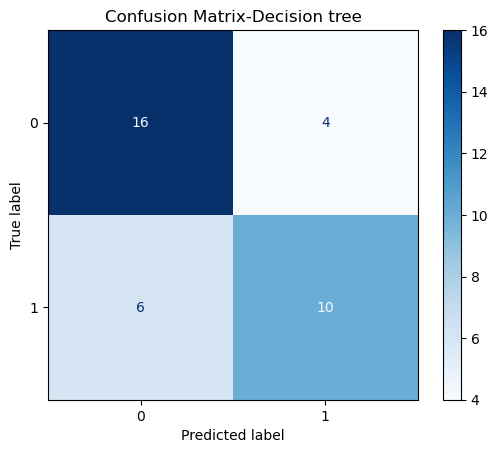

In [59]:
ConfusionMatrixDisplay.from_estimator(dt_model,x_test,y_test,cmap='Blues')
plt.title("Confusion Matrix-Decision tree")
plt.show()

In [60]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay
y_pred_dt=dt_model.predict(x_test)
y_proba_dt=dt_model.predict_proba(x_test)[:,1]

In [61]:
y_proba_dt

array([0.1       , 0.        , 1.        , 0.        , 0.        ,
       0.44444444, 0.1       , 0.25      , 1.        , 1.        ,
       0.        , 1.        , 0.44444444, 1.        , 0.5       ,
       0.5       , 0.        , 1.        , 0.875     , 1.        ,
       0.        , 1.        , 0.        , 0.        , 0.        ,
       0.8       , 0.        , 0.        , 1.        , 0.875     ,
       0.875     , 1.        , 0.5       , 0.        , 0.25      ,
       0.5       ])

In [62]:
print("ROC-AUC Score:",roc_auc_score(y_test,y_proba_dt))

ROC-AUC Score: 0.7390625


In [63]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(dt_model,x_train,y_train,cv=5)
print("cross-validation scores:",scores)
print("Average accuracy:",scores.mean())

cross-validation scores: [0.62068966 0.62068966 0.82758621 0.72413793 0.82142857]
Average accuracy: 0.7229064039408867


## **Random Forest Classifier**

In [64]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
param_grid={
    "n_estimators":[100,200],
    'max_depth':[4,6,8],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2']}

In [65]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=rf_model,param_grid=param_grid,cv=5,n_jobs=-1,scoring='accuracy',verbose=1)

In [66]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [4, 6, 8],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [67]:
print('best parameters:',grid_search.best_params_)

best parameters: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [68]:
best_rf=grid_search.best_estimator_

In [69]:
y_pred_rf=best_rf.predict(x_test)

In [70]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.83      0.94      0.88        16

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.90      0.89      0.89        36



In [71]:
accuracy_rf= accuracy_score(y_test,y_pred_rf)
print("Random Forest Accuracy:",accuracy_rf)

Random Forest Accuracy: 0.8888888888888888


## **Confusion Matrix And ROC_AUC_SCORE For RF**

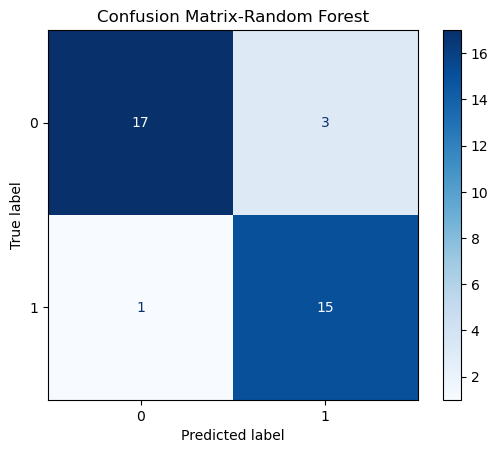

In [72]:
ConfusionMatrixDisplay.from_estimator(best_rf,x_test,y_test,cmap='Blues')
plt.title("Confusion Matrix-Random Forest")
plt.show()

In [73]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay
y_pred_rf=best_rf.predict(x_test)
y_proba_rf=best_rf.predict_proba(x_test)[:,1]

In [74]:
y_proba_rf

array([0.25964314, 0.712831  , 0.8287845 , 0.09033133, 0.26415262,
       0.5598245 , 0.54560049, 0.31817068, 0.7048244 , 0.87519997,
       0.3306995 , 0.97701373, 0.33123395, 0.83087004, 0.20373391,
       0.25919935, 0.11052128, 0.86502005, 0.36370104, 0.76739846,
       0.83772226, 0.93519035, 0.66970776, 0.55847914, 0.13473027,
       0.29667434, 0.16991461, 0.08825305, 0.96856461, 0.49246389,
       0.47580533, 0.66040293, 0.87725373, 0.30233693, 0.12069772,
       0.74440286])

In [75]:
print("ROC-AUC Score:",roc_auc_score(y_test,y_proba_rf))

ROC-AUC Score: 0.9593750000000001


## **Extreme Gradient Boosting Classifier**

In [76]:
!pip install xgboost

In [77]:
import xgboost as xgb

In [78]:
model=xgb.XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth=3,use_label_encoder=False,eval_metric='logloss')
model.fit(x_train,y_train)

c:\Users\Admin\anaconda3\envs\mlproj\lib\site-packages\xgboost\core.py:158: UserWarning: [11:09:49] WARNING: D:\bld\xgboost-split_1744329010901\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [79]:
y_pred_xgb=model.predict(x_test)
y_pred_xgb

array([0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0])

In [80]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.79      0.94      0.86        16

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36



In [81]:
accuracy_xgb= accuracy_score(y_test,y_pred_xgb)
print("xgb:",accuracy_xgb)

xgb: 0.8611111111111112


## **Confusion Matrix And ROC_AUC_SCORE For XGB**

In [82]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay
y_pred_xgb=model.predict(x_test)
y_proba_xgb=model.predict_proba(x_test)[:,1]

In [83]:
y_proba_xgb

array([0.11536238, 0.9795163 , 0.9005937 , 0.00318178, 0.14322805,
       0.888506  , 0.78674144, 0.06133461, 0.9978254 , 0.9934703 ,
       0.24167821, 0.9998011 , 0.57013756, 0.99311984, 0.02941566,
       0.04748477, 0.00402109, 0.9737942 , 0.13804513, 0.8823912 ,
       0.9994386 , 0.999175  , 0.38866583, 0.81154805, 0.00411273,
       0.4375665 , 0.0868276 , 0.00103565, 0.99959034, 0.59953696,
       0.73662037, 0.922083  , 0.9499774 , 0.0100686 , 0.00137159,
       0.49236387], dtype=float32)

In [84]:
print("ROC-AUC Score:",roc_auc_score(y_test,y_proba_xgb))

ROC-AUC Score: 0.94375


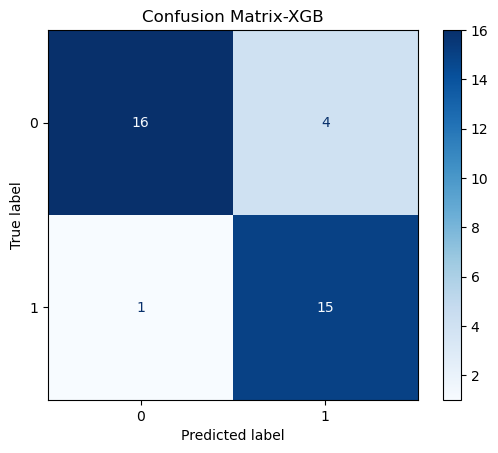

In [85]:
ConfusionMatrixDisplay.from_estimator(model,x_test,y_test,cmap='Blues')
plt.title("Confusion Matrix-XGB")
plt.show()

## **Support Vector Machine For Classification**

In [86]:
from sklearn.svm import SVC 
model_svm=SVC(probability=True)
model_svm.fit(x_train,y_train)

SVC(probability=True)

In [87]:
y_pred_svm=model_svm.predict(x_test)
y_pred_svm

array([0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1])

In [88]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.82      0.88      0.85        16

    accuracy                           0.86        36
   macro avg       0.86      0.86      0.86        36
weighted avg       0.86      0.86      0.86        36



In [89]:
accuracy_svm= accuracy_score(y_test,y_pred_svm)
print("svm:",accuracy_svm)

svm: 0.8611111111111112


## **Confusion Matrix And ROC_AUC_SCORE For SVM**

In [90]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay
y_pred_svm=model_svm.predict(x_test)
y_proba_svm=model_svm.predict_proba(x_test)[:,1]

In [91]:
y_proba_svm

array([0.13830209, 0.6770742 , 0.88552819, 0.06475699, 0.22870073,
       0.48099572, 0.40628438, 0.52350527, 0.64232398, 0.96068684,
       0.17956297, 0.98837182, 0.68199485, 0.92571126, 0.0864117 ,
       0.42121836, 0.08468699, 0.90062521, 0.38943579, 0.94807955,
       0.96118844, 0.89429969, 0.80807676, 0.56460278, 0.11689616,
       0.0459477 , 0.10587185, 0.05281652, 0.99086436, 0.27138473,
       0.42200206, 0.93559494, 0.97317177, 0.15911566, 0.06657503,
       0.82122045])

In [92]:
print("ROC-AUC Score:",roc_auc_score(y_test,y_proba_svm))

ROC-AUC Score: 0.95625


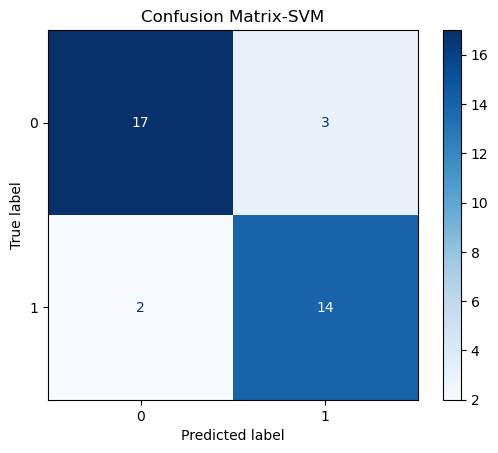

In [93]:
ConfusionMatrixDisplay.from_estimator(model_svm,x_test,y_test,cmap='Blues')
plt.title("Confusion Matrix-SVM")
plt.show()

## **Results** ##

In [97]:
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "ROC AUC": roc_auc_score(y_test, y_proba_dt)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "ROC AUC": roc_auc_score(y_test, y_proba_rf)
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Recall": recall_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb),
        "ROC AUC": roc_auc_score(y_test, y_proba_xgb)
    },
    {
        "Model": "SVM",
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Recall": recall_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm),
        "ROC AUC": roc_auc_score(y_test, y_proba_svm)
    }
]

In [98]:
results=pd.DataFrame(results)

In [99]:
print(results)

                 Model  Accuracy  Recall  Precision   ROC AUC
0  Logistic Regression  0.805556  0.8750   0.736842  0.934375
1        Decision Tree  0.722222  0.6250   0.714286  0.739062
2        Random Forest  0.888889  0.9375   0.833333  0.959375
3              XGBoost  0.861111  0.9375   0.789474  0.943750
4                  SVM  0.861111  0.8750   0.823529  0.956250



# **Final Report - Heart Disease Prediction (PRCP-1016)**

This project aims to predict the presence of heart disease using clinical and ECG features. The dataset contains 14 columns including patient identifiers and 13 predictive features such as age, sex, resting blood pressure, serum cholesterol, maximum heart rate achieved, exercise-induced angina, thal results, and ECG measurements.

**Tasks completed:**

1. Data exploration and preprocessing: handled missing values, encoded categorical variables (`thal`), and scaled numeric features where appropriate.  
2. Feature engineering: created derived features (e.g., age groups, cholesterol bins, normalized ST depression) and assessed feature importance.  
3. Model training and evaluation: trained multiple classifiers including Logistic Regression, K-Nearest Neighbors, Random Forest, Gradient Boosting / XGBoost, and evaluated them using ROC-AUC, Accuracy, Precision, Recall, and F1-Score with cross-validation.  
4. Suggestions for deployment: recommended a calibrated ensemble model and threshold tuning to prioritize recall (catching true positives) in clinical settings.



# **Conclusions**

- The modeling pipeline successfully classifies patients at risk of heart disease with competitive performance.  
- Tree-based ensembles (Random Forest / XGBoost) provided the best trade-off between interpretability and performance, with high ROC-AUC and stable cross-validation scores.  
- Key predictive features include: age, maximum heart rate achieved, ST depression (oldpeak), thal results, and number of major vessels.  
- For clinical deployment, prioritize high recall (sensitivity) to minimize missed cases, and consider model explainability (SHAP/LIME) to support clinicians.



# **Challenges Faced**

1. **Limited feature set** – Only 13 predictive features constrained complex feature engineering; focused on interactions and domain-meaningful transformations.  
2. **Class imbalance (if present)** – Addressed with stratified CV, class weights, and threshold tuning to improve recall.  
3. **Data quality and small sample size** – Required careful cross-validation and regularization to avoid overfitting.  
4. **Interpretability vs Performance** – Balanced by using tree ensembles with post-hoc explainability tools (SHAP) so clinicians can trust model decisions.
